# Full Trenberth Diagram Calibration

This notebook calibrates **23 parameters** spanning shortwave radiation, longwave radiation, surface albedo, and land hydrology to simultaneously match the [Trenberth et al. (2009)](https://doi.org/10.1175/2008BAMS2634.1) global energy budget across **6 fluxes**:

| Flux | Target | Description |
|------|--------|-------------|
| OSR  | 101.9 W/m² | Outgoing shortwave at top-of-atmosphere |
| SRU  | 23.0 W/m²  | Surface shortwave reflected upward |
| SRD  | 168.0 W/m² | Surface shortwave absorbed downward |
| OLR  | 235.0 W/m² | Outgoing longwave at top-of-atmosphere |
| LRD  | 333.0 W/m² | Surface longwave downward (greenhouse back-radiation) |
| LRU  | 398.0 W/m² | Surface longwave upward (Stefan-Boltzmann emission) |

This is an extension of `radiation_sw.ipynb`: we add longwave emissivities and land-hydrology parameters. Including OLR in the loss couples the SW and LW optimisation — changing cloud albedo now also feeds back through the LW budget via surface temperature.

**Expected runtime:** ~8–12 hours at T31. Use Section 5 (quick test) first.

## 1. Setup

In [39]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using SpeedyCalibration
using Optimisers
using CairoMakie
using GeoMakie
using Dates
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`


## 2. Define Trainable Parameters

We train **23 parameters** across four modules. All paths and bounds are copied
directly from `full_trend_birth_training.ipynb`.

**`absorptivity_water_vapor` needs `grad_scale=0.01`.**
The physical gradient is ~200× weaker than the cloud parameters because it is
multiplied by specific humidity (q ≈ 0.005). Its lower bound is 60 (not 0) because
the model becomes numerically unstable below ~57.

**`snow_melting_threshold` needs `grad_scale=0.01`.**
Measured in Kelvin (~275 K), so a 1 W/m² flux change produces a ~100× smaller
raw gradient than dimensionless parameters.

**Parameters with zero gradient (excluded):**
- `conv_time_scale` — integer conversion in `Second(time_scale).value` is opaque to Enzyme
- `lsc_rh_threshold` — step-function boundary; gradient is zero almost everywhere


In [40]:
param_specs = [
    # ── SW cloud reflection ───────────────────────────────────────────────────
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_albedo,
        [:shortwave_radiation, :clouds, :stratocumulus_albedo];
        bounds=(0.10f0, 0.90f0), initial=0.50f0),
    ParamSpec(:precipitation_weight,
        [:shortwave_radiation, :clouds, :precipitation_weight];
        bounds=(0.0f0, 0.8f0), initial=0.20f0),

    # ── SW atmospheric absorption ─────────────────────────────────────────────
    ParamSpec(:absorptivity_water_vapor,
        [:shortwave_radiation, :transmissivity, :absorptivity_water_vapor];
        bounds=(60f0, 140f0), initial=75f0, grad_scale=0.01f0),
    ParamSpec(:absorptivity_dry_air,
        [:shortwave_radiation, :transmissivity, :absorptivity_dry_air];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),
    ParamSpec(:absorptivity_aerosol,
        [:shortwave_radiation, :transmissivity, :absorptivity_aerosol];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),
    ParamSpec(:ozone_absorption,
        [:shortwave_radiation, :radiative_transfer, :ozone_absorption];
        bounds=(0.002f0, 0.020f0), initial=0.01f0),

    # ── Surface albedo ────────────────────────────────────────────────────────
    ParamSpec(:albedo_land,
        [:albedo, :land, :albedo_land];
        bounds=(0.10f0, 0.70f0), initial=0.40f0),
    ParamSpec(:albedo_high_vegetation,
        [:albedo, :land, :albedo_high_vegetation];
        bounds=(0.04f0, 0.26f0), initial=0.15f0),
    ParamSpec(:albedo_low_vegetation,
        [:albedo, :land, :albedo_low_vegetation];
        bounds=(0.05f0, 0.35f0), initial=0.20f0),
    ParamSpec(:albedo_snow,
        [:albedo, :land, :albedo_snow];
        bounds=(0.15f0, 0.75f0), initial=0.40f0),
    ParamSpec(:snow_depth_scale,
        [:albedo, :land, :snow_depth_scale];
        bounds=(0.005f0, 0.20f0), initial=0.05f0),
    ParamSpec(:albedo_ocean,
        [:albedo, :ocean, :albedo_ocean];
        bounds=(0.02f0, 0.10f0), initial=0.06f0),
    ParamSpec(:albedo_ice,
        [:albedo, :ocean, :albedo_ice];
        bounds=(0.30f0, 0.90f0), initial=0.60f0),

    # ── Longwave transmissivity (Frierson scheme) ─────────────────────────────
    # τ₀_equator and τ₀_pole control optical depth; fₗ is the LW fraction.
    ParamSpec(:tau0_equator,
        [:longwave_radiation, :transmissivity, :τ₀_equator];
        bounds=(2f0, 12f0), initial=6f0),
    ParamSpec(:tau0_pole,
        [:longwave_radiation, :transmissivity, :τ₀_pole];
        bounds=(0.3f0, 4f0), initial=1.5f0),
    ParamSpec(:fl,
        [:longwave_radiation, :transmissivity, :fₗ];
        bounds=(0.0f0, 0.5f0), initial=0.1f0),

    # ── Longwave emissivity ───────────────────────────────────────────────────
    ParamSpec(:emissivity_ocean,
        [:longwave_radiation, :radiative_transfer, :emissivity_ocean];
        bounds=(0.80f0, 1.00f0), initial=0.98f0),
    ParamSpec(:emissivity_land,
        [:longwave_radiation, :radiative_transfer, :emissivity_land];
        bounds=(0.80f0, 1.00f0), initial=0.98f0),

    # ── Land hydrology ────────────────────────────────────────────────────────
    ParamSpec(:infiltration_fraction,
        [:land, :soil_moisture, :infiltration_fraction];
        bounds=(0.05f0, 0.80f0), initial=0.25f0),
    ParamSpec(:ocean_moisture,
        [:land, :soil_moisture, :ocean_moisture];
        bounds=(0.0f0, 1.0f0), initial=0.0f0),
    ParamSpec(:snow_melting_threshold,
        [:land, :snow, :melting_threshold];
        bounds=(270f0, 280f0), initial=275f0, grad_scale=0.01f0),
]

println("$(length(param_specs)) trainable parameters defined.")


23 trainable parameters defined.


## 3. Configure the Loss Function

`TRENBERTH_LOSS` targets all 6 SW+LW fluxes. OLR and OSR receive full weight (1.0); surface fluxes receive lower weight (0.3–0.5) reflecting their larger observational uncertainty.

In [41]:
loss_config = TRENBERTH_LOSS

println("Loss configuration: $(length(loss_config.flux_keys))-flux MSE")
println()
@printf("  %-6s  %8s  %6s\n", "flux", "target", "weight")
println("  " * "-" ^ 24)
for k in loss_config.flux_keys
    @printf("  %-6s  %6.1f W/m²  %.1f\n",
            k, loss_config.targets[k], loss_config.weights[k])
end

Loss configuration: 6-flux MSE

  flux      target  weight
  ------------------------
  osr      101.9 W/m²  1.0
  sru       23.1 W/m²  0.5
  srd      184.3 W/m²  0.5
  olr      235.0 W/m²  1.0
  lrd      333.0 W/m²  0.3
  lru      398.0 W/m²  0.3


## 4. Quick Test

Verify all parameter paths are correct and Enzyme can differentiate through everything before the full run.

> **Note:** `calibrate!` warms up Enzyme automatically on the actual training model (`warmup_enzyme=true` by default). Expect *"Enzyme warmup complete in X s."* before the spinup on the first call. Pass `warmup_enzyme=false` on subsequent calls in the same session.

In [42]:
result_test = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    quick_test_config(),
)

println("Quick test complete: ", result_test.conv_info.stop_reason)

# Check gradient magnitudes — a zero gradient for any parameter is a red flag
println("\nGradient magnitudes (last batch):")
@printf("  %-28s  %12s\n", "parameter", "|mean grad|")
println("  " * "-" ^ 45)
for spec in result_test.param_specs
    g = result_test.history[Symbol("grad_", spec.name)]
    isempty(g) && continue
    @printf("  %-28s  %12.3e\n", spec.name, abs(g[end]))
end

[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl — calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123


Starting training...
----------------------------------------------------------------------
Batch 1: all gradient samples invalid, stopping.

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.6000
  stratocumulus_cover_max          0.6000 → 0.6000
  stratocumulus_albedo             0.5000 → 0.5000
  precipitation_weight             0.2000 → 0.2000
  absorptivity_water_vapor         75.0000 → 75.0000
  absorptivity_dry_air             0.0314 → 0.0314
  absorptivity_aerosol             0.0314 → 0.0314
  ozone_absorption                 0.0100 → 0.0100
  albedo_land                      0.4000 → 0.4000
  albedo_high_vegetation           0.1500 → 0.1500
  albedo_low_vegetation            0.2000 → 0.2000
  albedo_snow                      0.4000 → 0.4000
  snow_depth_scale                 0.0500 → 0.0500
  albedo_ocean                     0.0600 → 0.0600
  albedo_ice                       0.6000 → 0.6000
  tau0_equator                     6.0000 → 6.0000
  tau0_pole            

**Interpreting gradient magnitudes:**  
- All gradients should be non-zero. A zero gradient means the parameter is disconnected from the loss through the AD graph — check the path or exclude the parameter.
- If one gradient is 100× larger than the others, consider increasing `grad_scale` for the weaker ones, or reducing it for the outlier.

---

## 5. Full Training Run

**⏱ Expected runtime: ~8–12 hours at T31.**

We use a slightly lower initial LR (`5f-3`) compared to the SW-only run because the 6-flux loss is more sensitive and can oscillate with a high LR.

In [43]:
# HP choice backed by a corrected T15 diagnostic sweep (see trenberth_hp_sweep.ipynb):
# batch_days=10 beat 1 and 3 at every LR tested (1e-3/5e-3/1e-2), and LR=1e-2 was the
# best of those. The earlier "batch_days=10" recommendation from this repo's original
# sweep was coincidentally right but for a broken reason -- with daily_cycle=true,
# steps_per_day=36 at trunc=31 (Delta t=40min), and the old samples_per_batch=20 gives
# steps_per_sample=18 steps = EXACTLY 12h, so every batch resampled the same 2 clock
# times forever (hard diurnal aliasing). samples_per_batch=32 here gives
# steps_per_sample=360/32=11 steps (~7.3h), and gcd(11,36)=1 so the 32 samples/batch
# actually sweep almost the full 36-slot diurnal cycle -- no aliasing.
result = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    TrainingConfig(
        spinup_days       = 180,
        batch_days        = 10.0,
        samples_per_batch = 32,
        max_batches       = 300,
        loss_threshold    = 500f0,
        trunc             = 31,
        nlayers            = 8,
        daily_cycle       = true,   # required: physical diurnal cycle must stay on
    ),
)

save_path = joinpath(@__DIR__, "output", "trenberth_full_result.jld2")
mkpath(dirname(save_path))
save_result(result, save_path)
println("Result saved to: $save_path")

SpeedyCalibration.jl — calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                

   0%  ETA: 4:10:09 (2000-09-16, 572.83 years/day, 109 m/s, [ -87,   28] ˚C)m

Spinup complete in 74.5 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.4 s.


   0%  ETA: 4:11:21 (2000-09-17, 570.08 years/day, 105 m/s, [ -87,   29] ˚C)

Starting training...
----------------------------------------------------------------------


...

Batch  40 | LR 1.0e-02 | osr= 90.6 sru= 26.0 srd=181.3 olr=250.9 lrd=349.1 lru=401.5 | L̄   553.72 | Δp 3.0e-03


   2%  ETA: 8:19:18 (2001-12-10, 283.43 years/day, 104 m/s, [-111,   30] ˚C)

Batch  45 | LR 1.0e-02 | osr= 92.4 sru= 26.1 srd=179.1 olr=248.6 lrd=350.4 lru=402.2 | L̄   506.04 | Δp 3.0e-03


   2%  ETA: 8:20:22 (2001-12-20, 282.74 years/day, 103 m/s, [-114,   30] ˚C)

CONVERGED: smoothed_loss 496.6154 < 500.0000

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.6731
  stratocumulus_cover_max          0.6000 → 0.6646
  stratocumulus_albedo             0.5000 → 0.5741
  precipitation_weight             0.2000 → 0.2740
  absorptivity_water_vapor         75.0000 → 76.0529
  absorptivity_dry_air             0.0314 → 0.0288
  absorptivity_aerosol             0.0314 → 0.0314
  ozone_absorption                 0.0100 → 0.0088
  albedo_land                      0.4000 → 0.4632
  albedo_high_vegetation           0.1500 → 0.1737
  albedo_low_vegetation            0.2000 → 0.2318
  albedo_snow                      0.4000 → 0.4719
  snow_depth_scale                 0.0500 → 0.0366
  albedo_ocean                     0.0600 → 0.0685
  albedo_ice                       0.6000 → 0.6721
  tau0_equator                     6.0000 → 7.1578
  tau0_pole                        1.5000 → 1.8916
  fl                               0.1000 → 0.1457
  emissivity_ocea

## 6. Inspect Results

In [44]:
println(result)
println()
println("Convergence info:")
println("  stop_reason:        ", result.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2))
println("  total_batches:      ", result.conv_info.total_batches)
@printf("  total_time:         %.1f hours\n", result.conv_info.total_time / 3600)

TrainingResult(46 batches, stop=smoothed loss below threshold (500.0), best_loss=496.6154)

Convergence info:
  stop_reason:        smoothed loss below threshold (500.0)
  best_smoothed_loss: 496.62
  total_batches:      46
  total_time:         0.1 hours


In [45]:
# Parameter table: initial → trained
@printf("\n%-28s  %10s  %10s  %10s\n", "parameter", "initial", "trained", "change")
println("-" ^ 65)
for spec in result.param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result.final_params[spec.name]
    @printf("%-28s  %10.4g  %10.4g  %+10.4g\n",
            spec.name, init, trained, trained - init)
end


parameter                        initial     trained      change
-----------------------------------------------------------------
cloud_albedo                         0.6      0.6731    +0.07309
stratocumulus_cover_max              0.6      0.6646    +0.06463
stratocumulus_albedo                 0.5      0.5741    +0.07413
precipitation_weight                 0.2       0.274    +0.07396
absorptivity_water_vapor              75       76.05      +1.053
absorptivity_dry_air             0.03135     0.02882   -0.002532
absorptivity_aerosol             0.03135     0.03141  +6.465e-05
ozone_absorption                    0.01    0.008829   -0.001171
albedo_land                          0.4      0.4632    +0.06325
albedo_high_vegetation              0.15      0.1737    +0.02365
albedo_low_vegetation                0.2      0.2318     +0.0318
albedo_snow                          0.4      0.4719    +0.07189
snow_depth_scale                    0.05     0.03659    -0.01341
albedo_ocean           

In [46]:
# Flux bias at end of training
@printf("\n%-6s  %8s  %8s  %8s\n", "flux", "target", "trained", "bias")
println("-" ^ 38)
for k in result.loss_config.flux_keys
    tgt  = result.loss_config.targets[k]
    val  = result.history[k][end]
    @printf("%-6s  %8.2f  %8.2f  %+8.2f\n", k, tgt, val, val - tgt)
end


flux      target   trained      bias
--------------------------------------
osr       101.90     92.07     -9.83
sru        23.10     26.22     +3.12
srd       184.30    179.28     -5.02
olr       235.00    248.60    +13.60
lrd       333.00    350.63    +17.63
lru       398.00    401.87     +3.87


## 7. Plot Training History

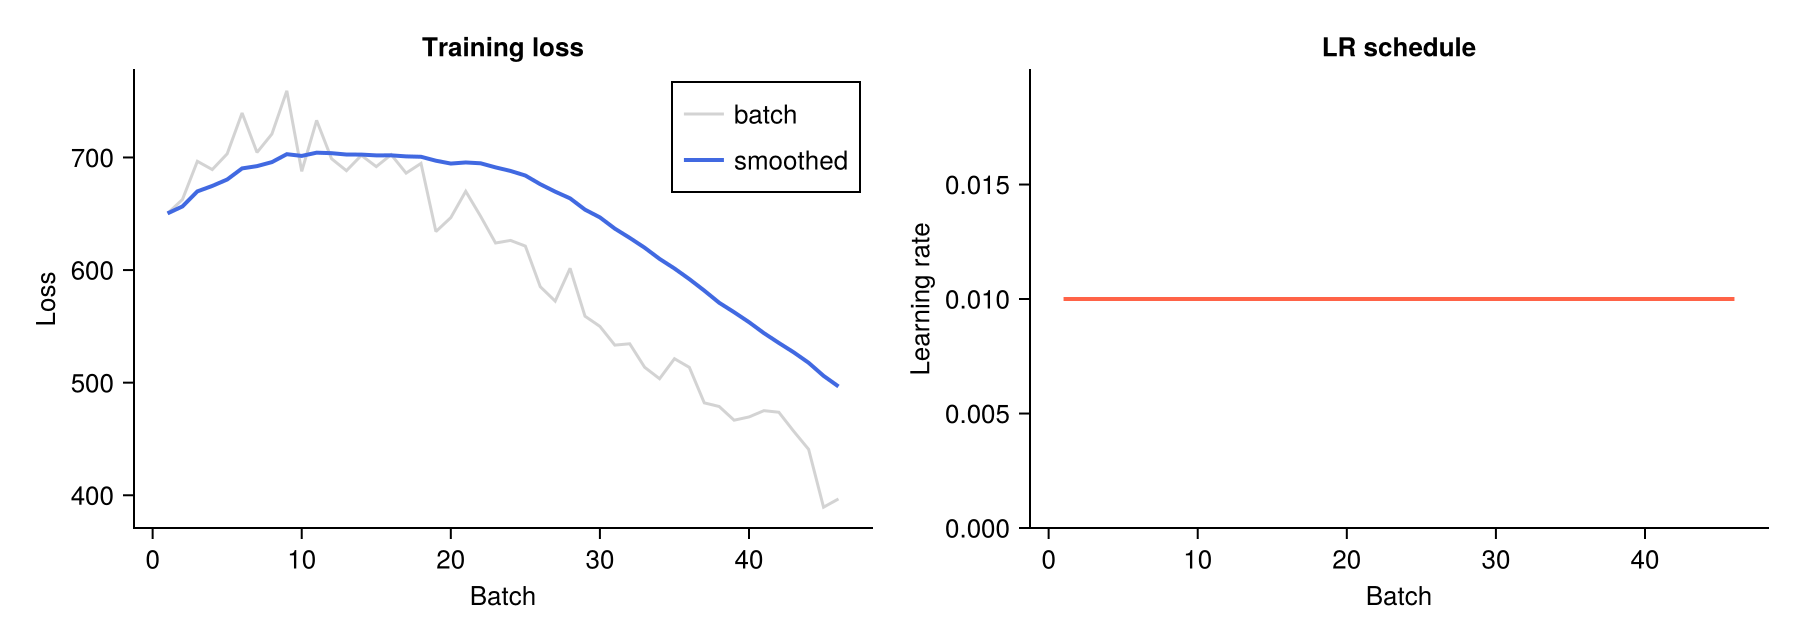

In [47]:
figs = plot_training(result; save_dir=joinpath(@__DIR__, "output", "trenberth_full"))
figs.fig_loss

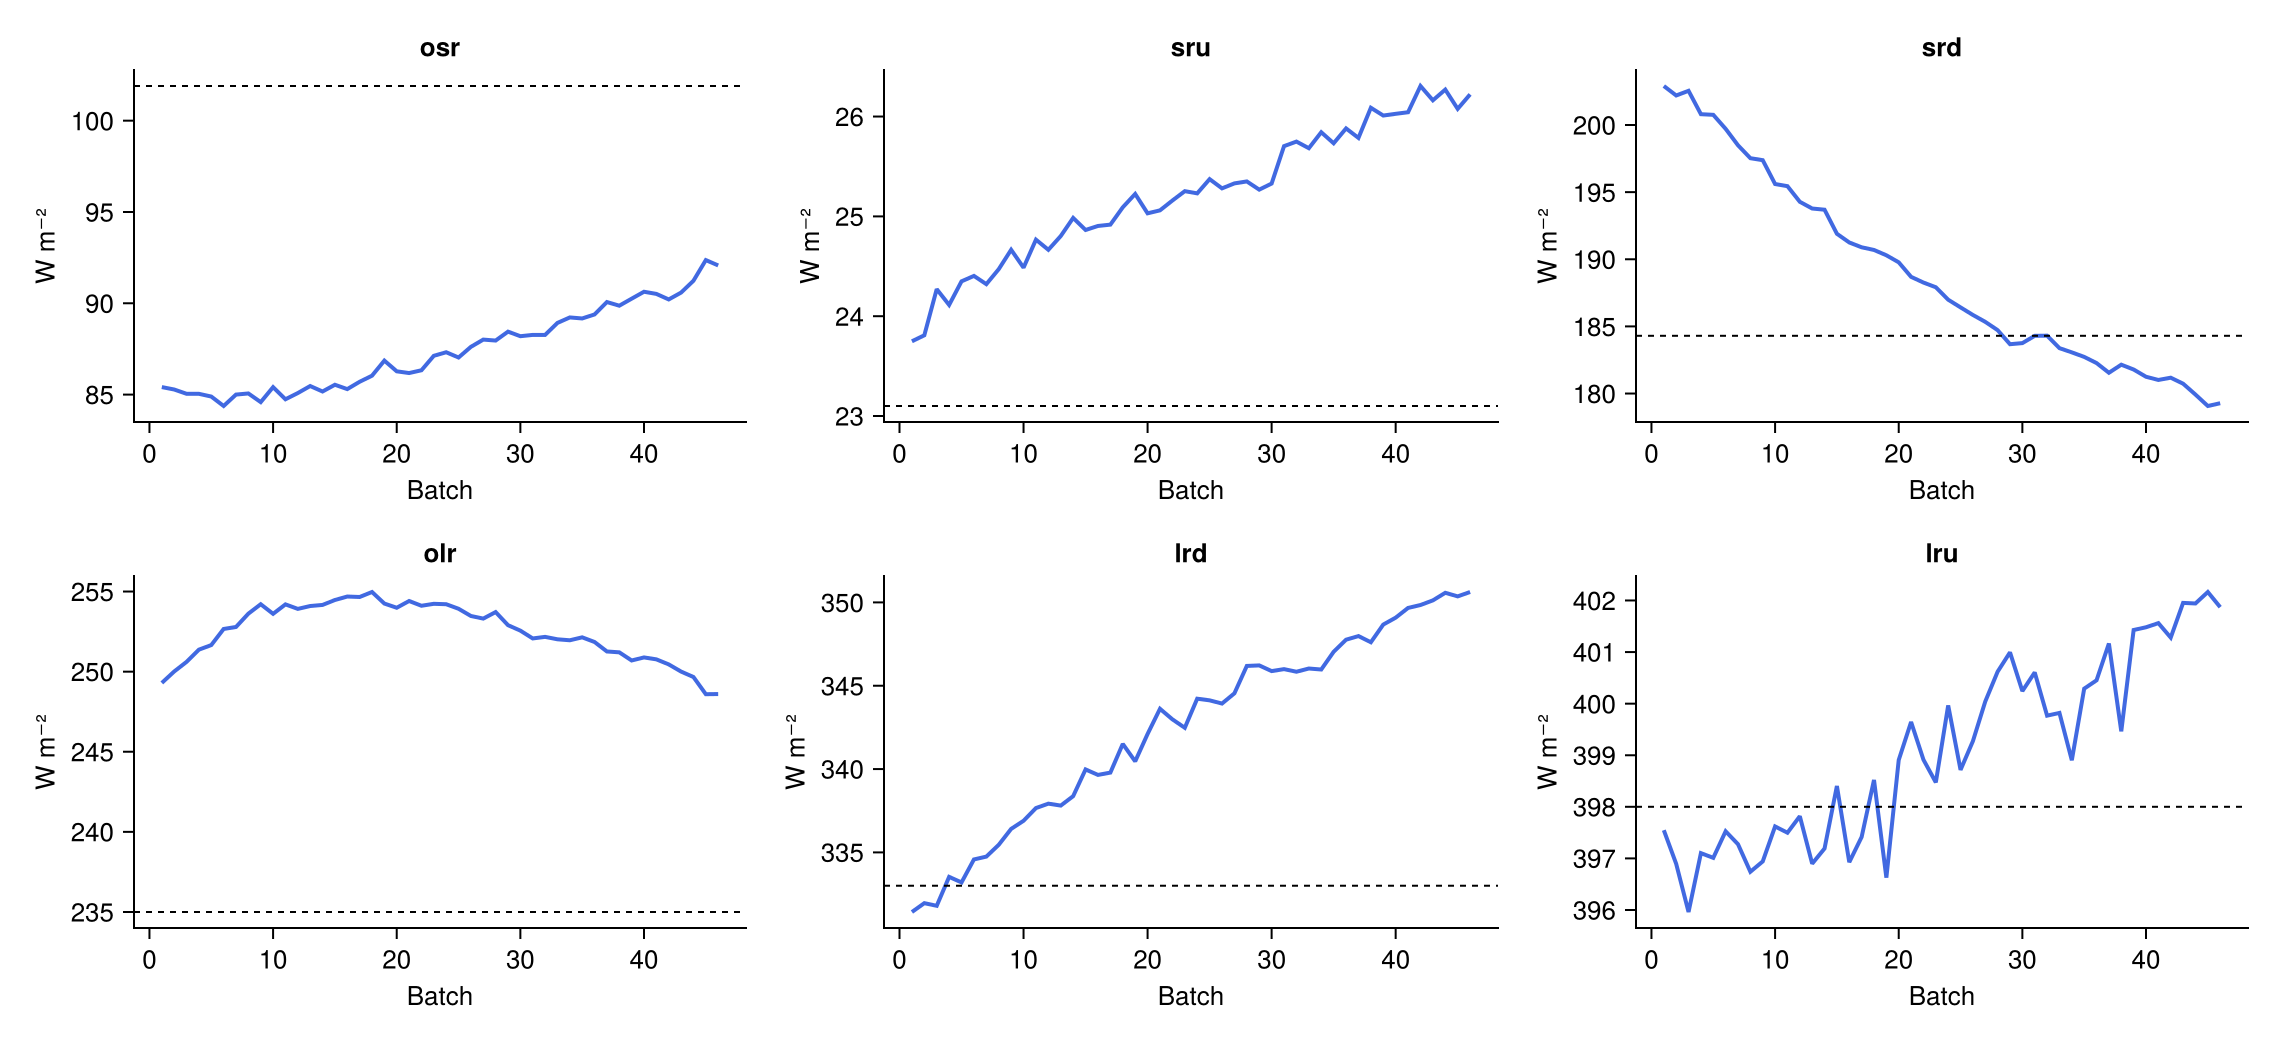

In [48]:
figs.fig_flux

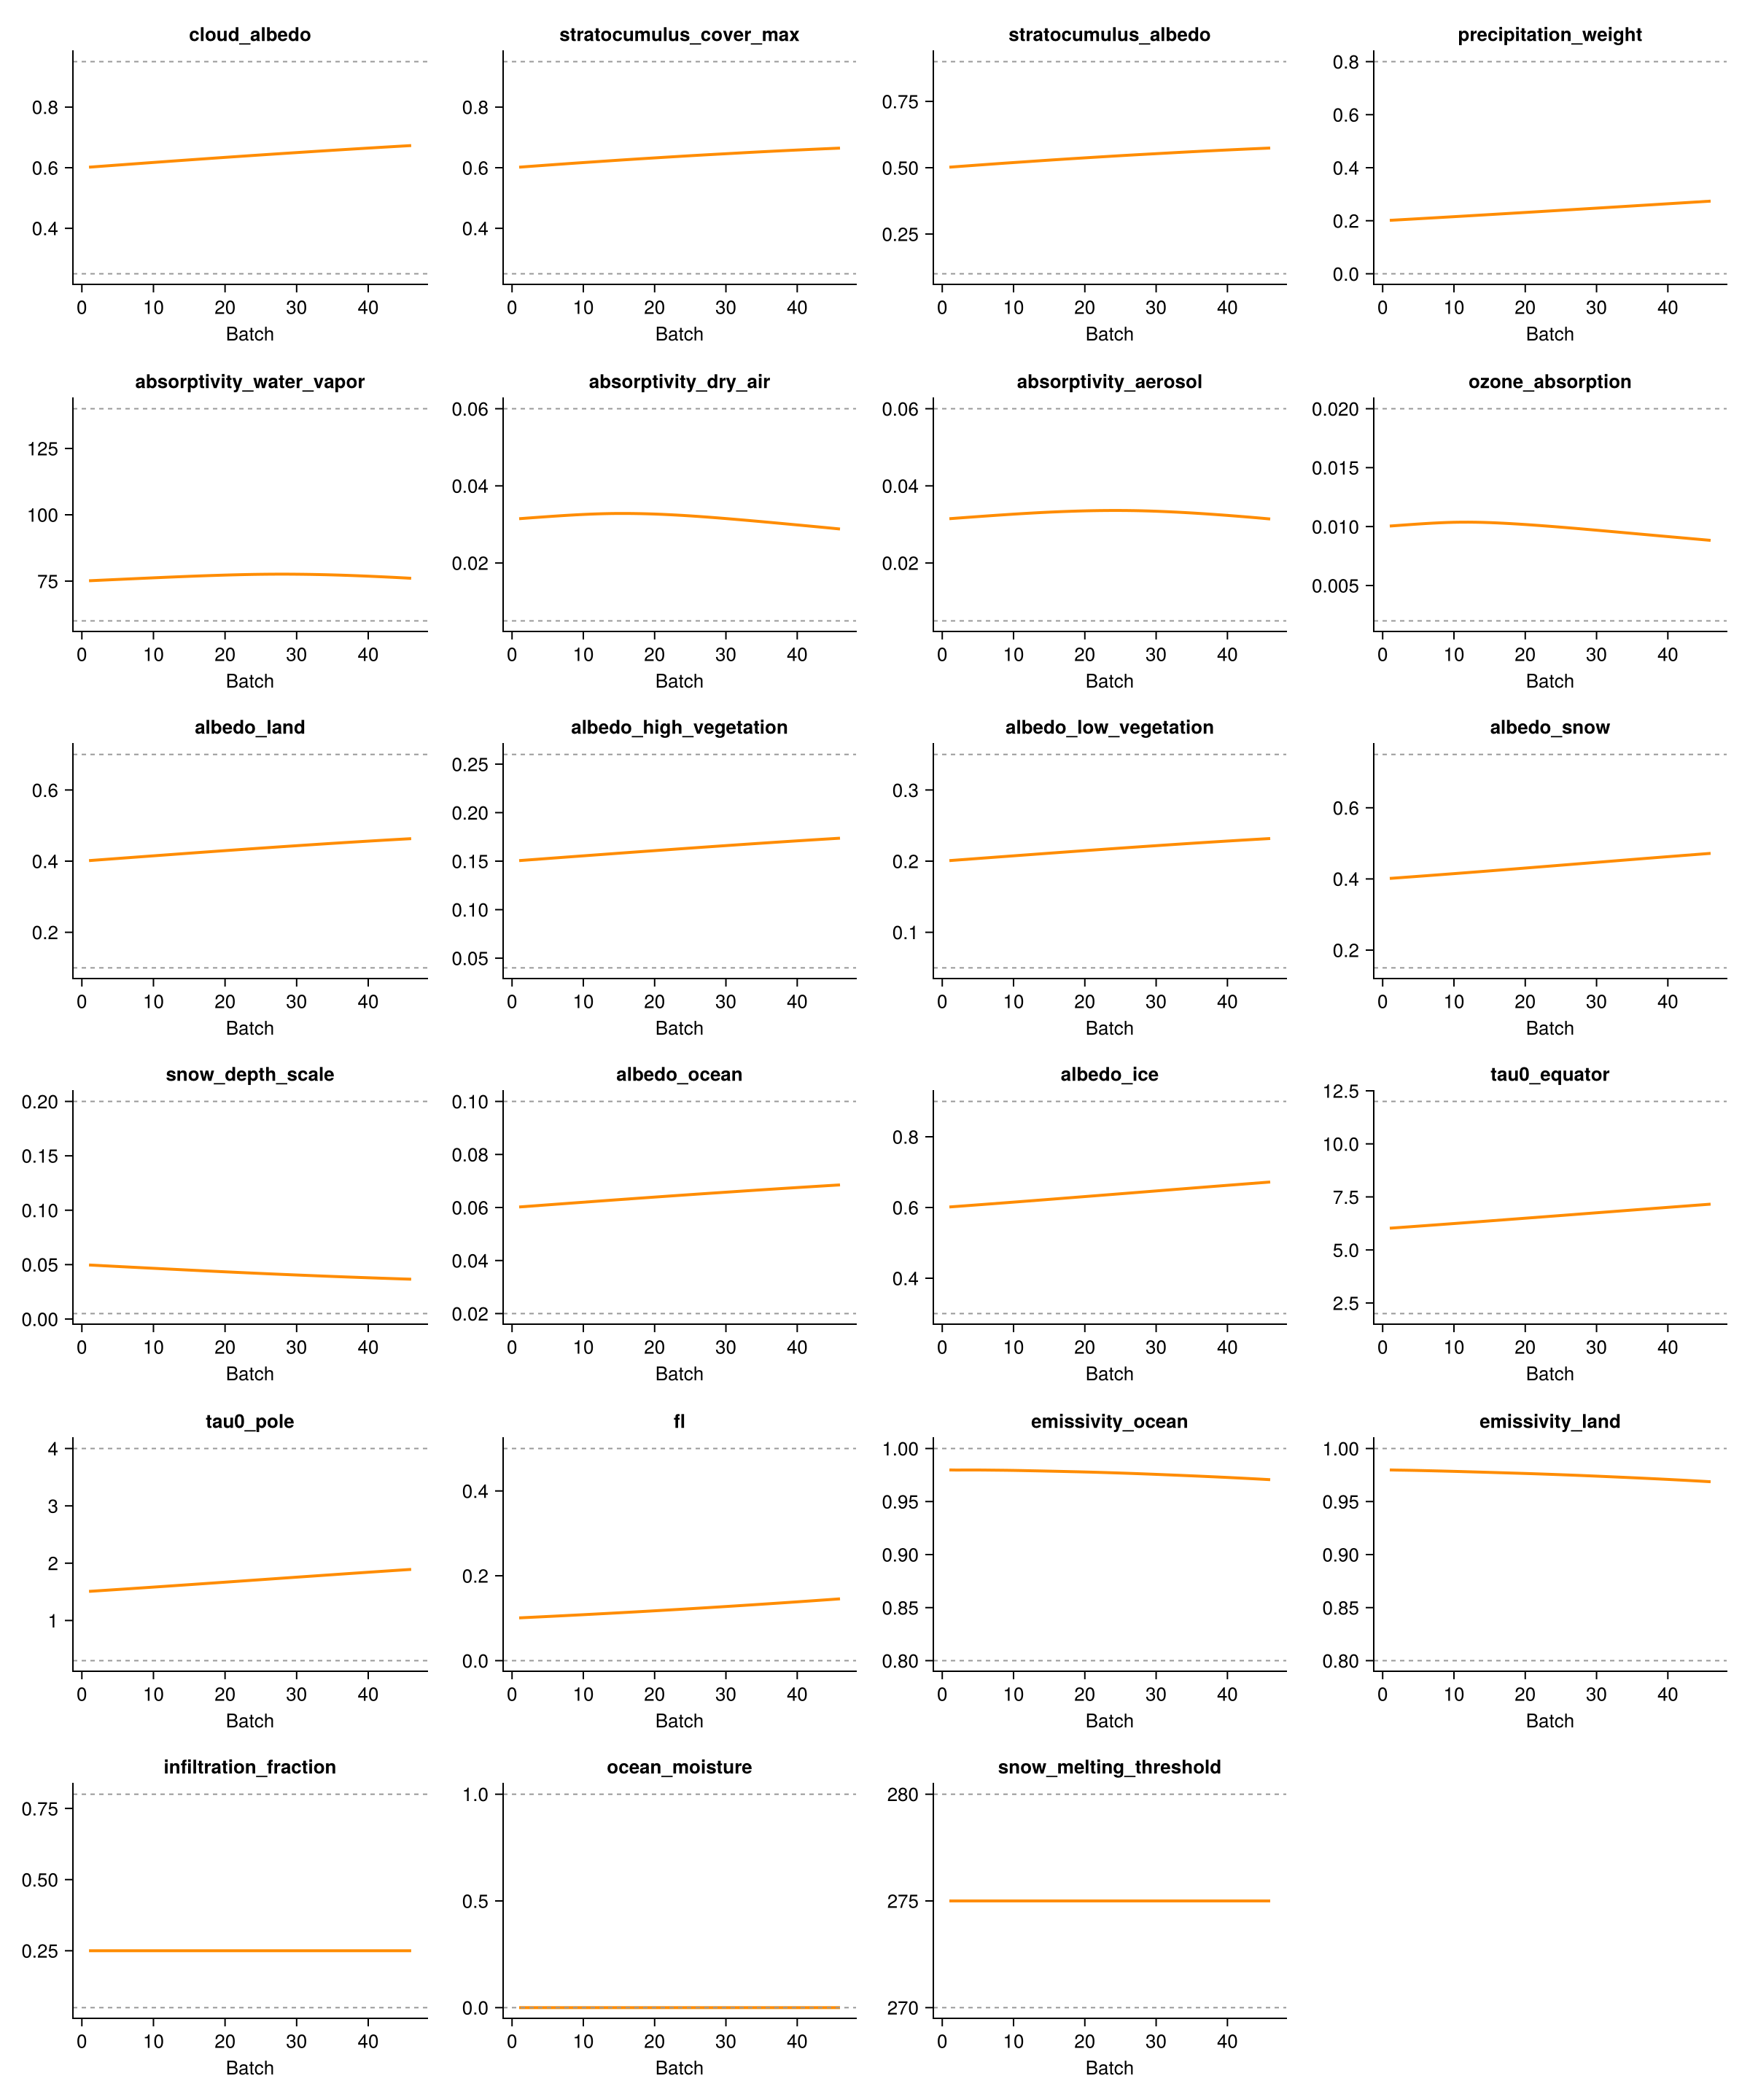

In [49]:
figs.fig_params

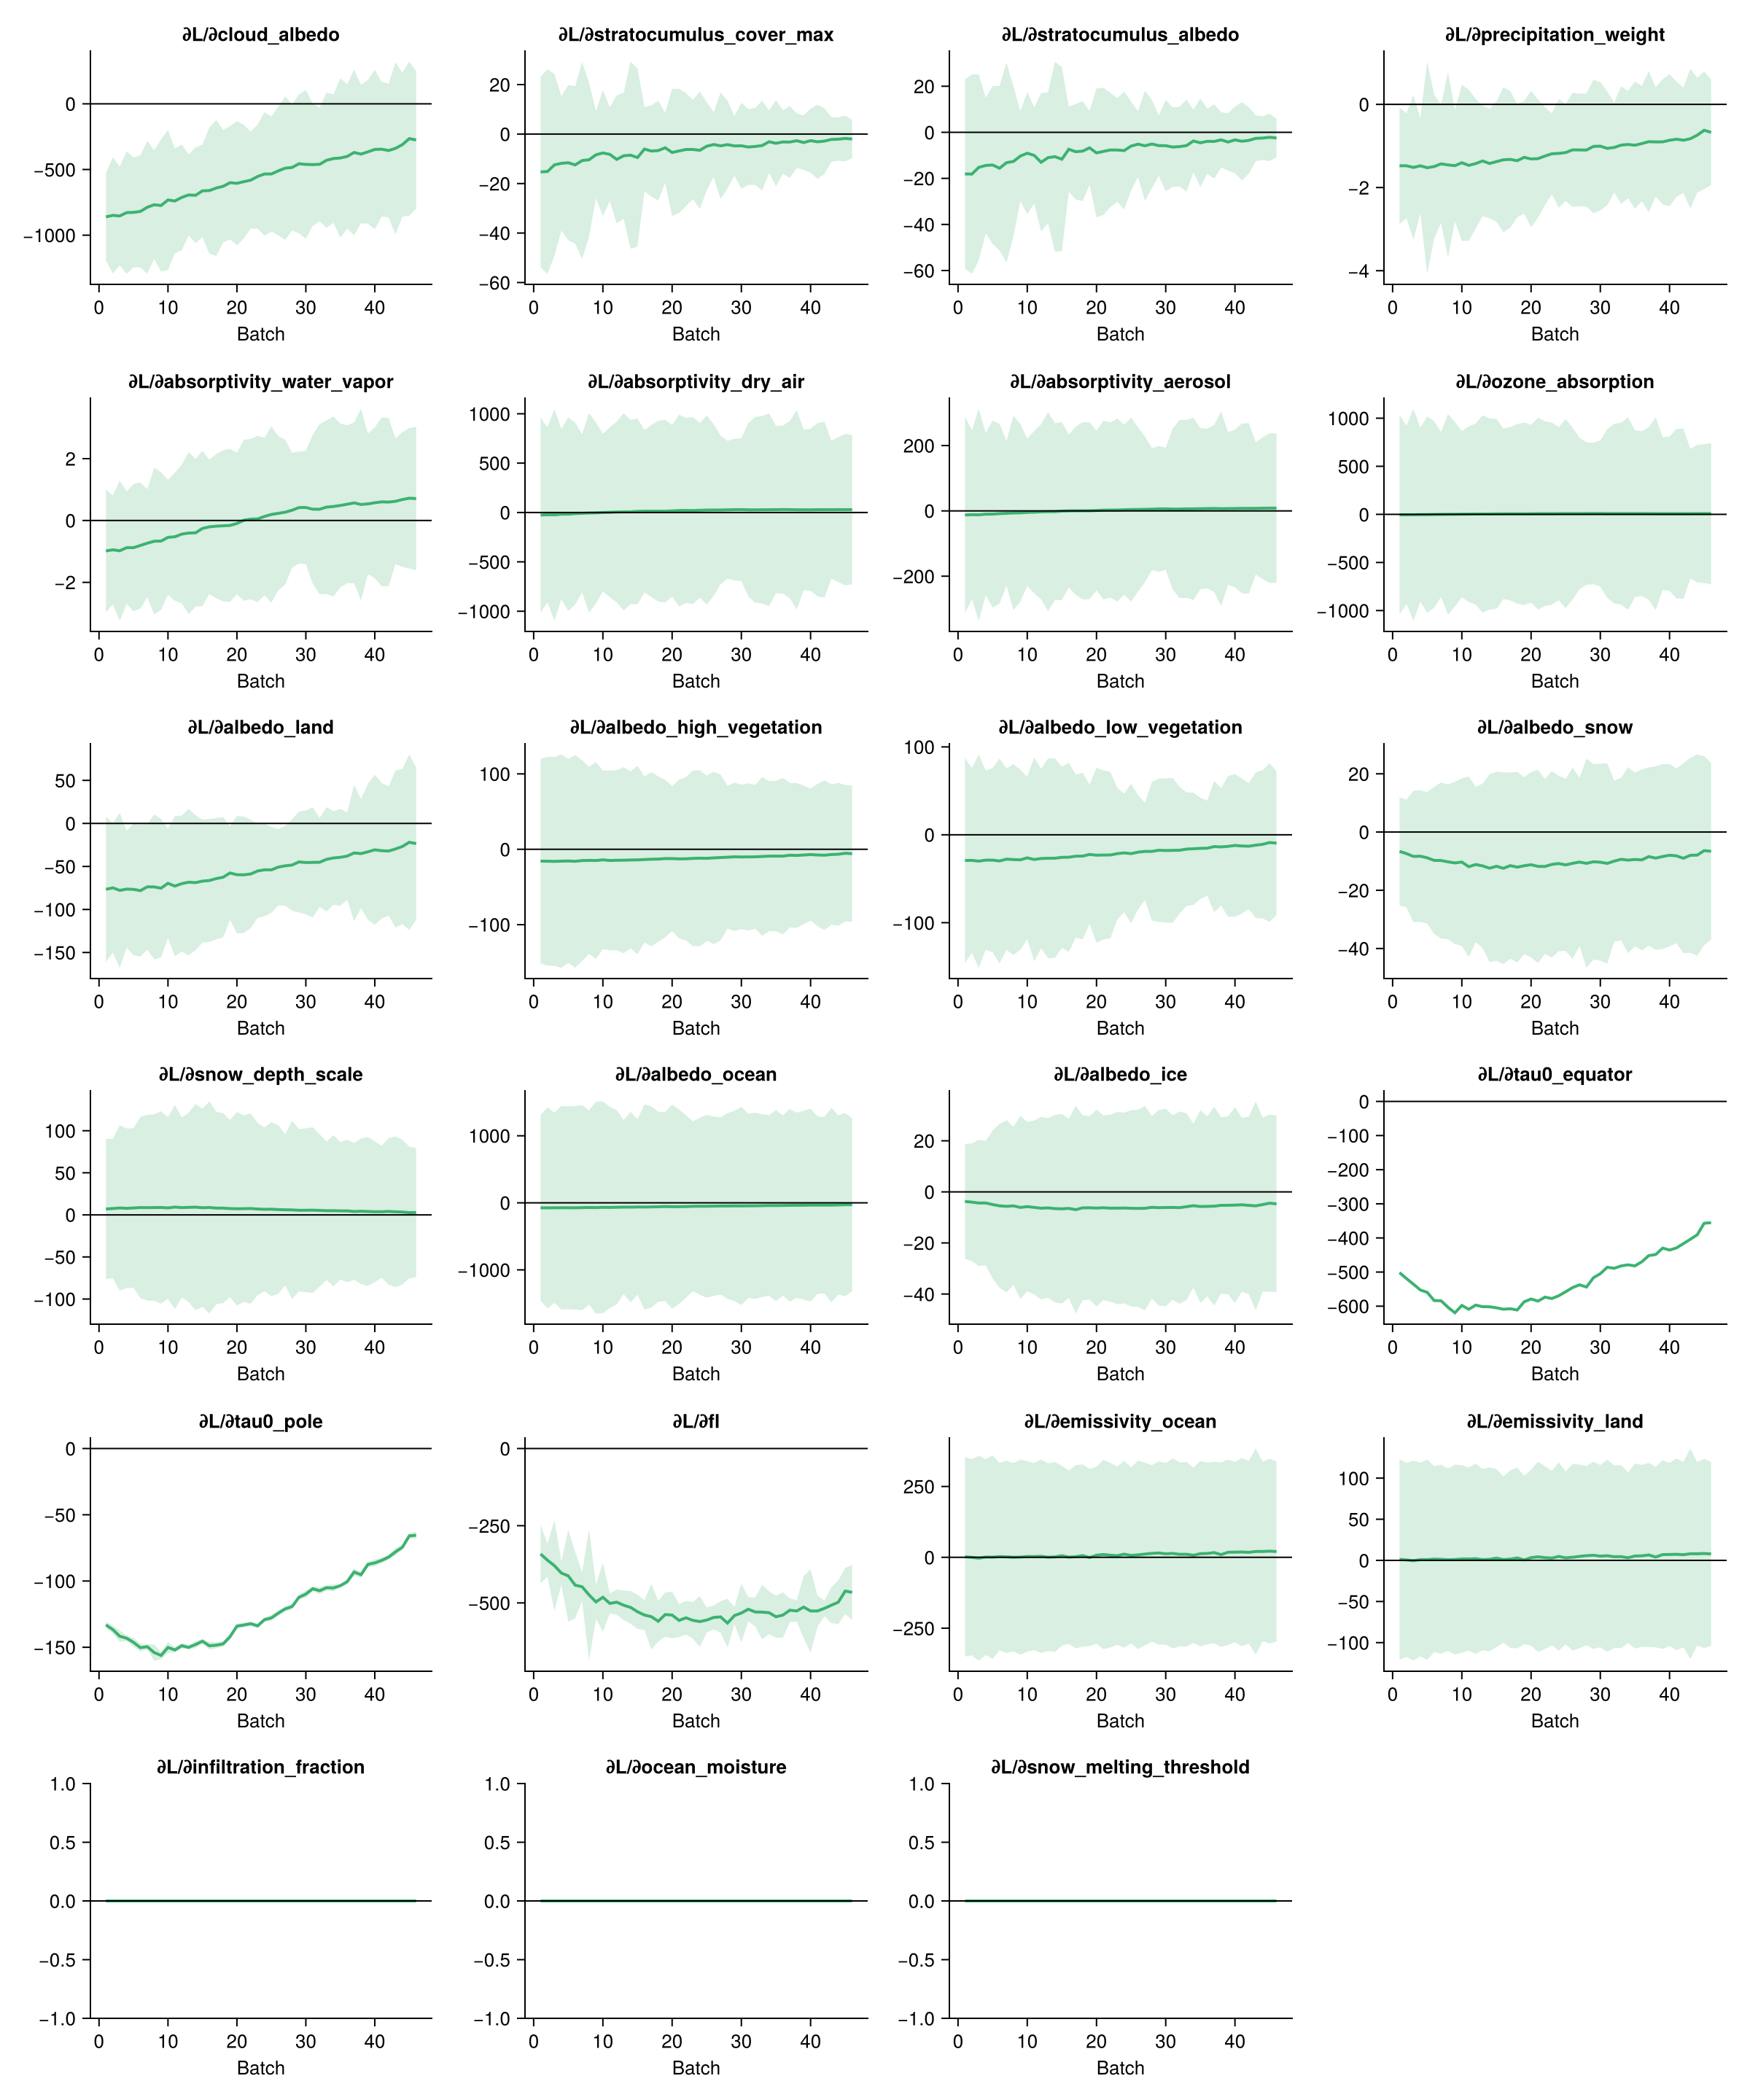

In [50]:
figs.fig_grads

## 8. Climate Validation

We compare the default model's equilibrium climatology against the trained one across all 6 target fluxes, precipitation, and the temperature profile.

**⏱ Expected runtime: ~1–3 hours at T31.**

In [51]:
clm = run_climate_validation(result; n_years=7, stat_years=5, dt=Minute(20))

Climate run: default ...


 100% Time: 0:31:28 (2007-03-20, 320.17 years/day,  99 m/s, [-102,   44] ˚C)


Climate run: trained ...


 100% Time: 0:31:58 (2007-03-20, 315.30 years/day, 104 m/s, [-117,   34] ˚C)


(default = (osr = 72.846504f0, olr = 272.45572f0, srd = 177.56392f0, sru = 17.853838f0, lrd = 341.8073f0, lru = 399.00992f0, precip_total = 3.2176092f0, temp_profile = Float32[254.33943, 245.0881, 246.5963, 250.99757, 259.19992, 266.8099, 273.2447, 279.63647]), trained = (osr = 80.82544f0, olr = 262.09146f0, srd = 165.9551f0, sru = 18.48746f0, lrd = 360.01938f0, lru = 403.579f0, precip_total = 3.26871f0, temp_profile = Float32[237.58932, 239.5502, 246.69637, 253.88312, 262.5062, 269.9516, 276.25946, 282.36908]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lrd, lru, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64

In [52]:
# Full bias comparison table
targets = result.loss_config.targets

@printf("%-6s  %8s  %9s  %9s  %9s  %9s\n",
        "flux", "target",
        "def val", "def bias",
        "trn val", "trn bias")
println("-" ^ 60)
for k in result.loss_config.flux_keys
    tgt    = targets[k]
    d_val  = getproperty(clm.default, k)
    t_val  = getproperty(clm.trained, k)
    @printf("%-6s  %8.2f  %9.2f  %+9.2f  %9.2f  %+9.2f\n",
            k, tgt, d_val, d_val-tgt, t_val, t_val-tgt)
end
println()

# Also show precipitation (not in the loss — a held-out diagnostic)
println("Held-out diagnostics (not in loss):")
@printf("  Precipitation:  default = %.2f mm/day  trained = %.2f mm/day  (ERA5 ≈ 2.74)\n",
        clm.default.precip_total, clm.trained.precip_total)

flux      target    def val   def bias    trn val   trn bias
------------------------------------------------------------
osr       101.90      72.85     -29.05      80.83     -21.07
sru        23.10      17.85      -5.25      18.49      -4.61
srd       184.30     177.56      -6.74     165.96     -18.34
olr       235.00     272.46     +37.46     262.09     +27.09
lrd       333.00     341.81      +8.81     360.02     +27.02
lru       398.00     399.01      +1.01     403.58      +5.58

Held-out diagnostics (not in loss):
  Precipitation:  default = 3.22 mm/day  trained = 3.27 mm/day  (ERA5 ≈ 2.74)


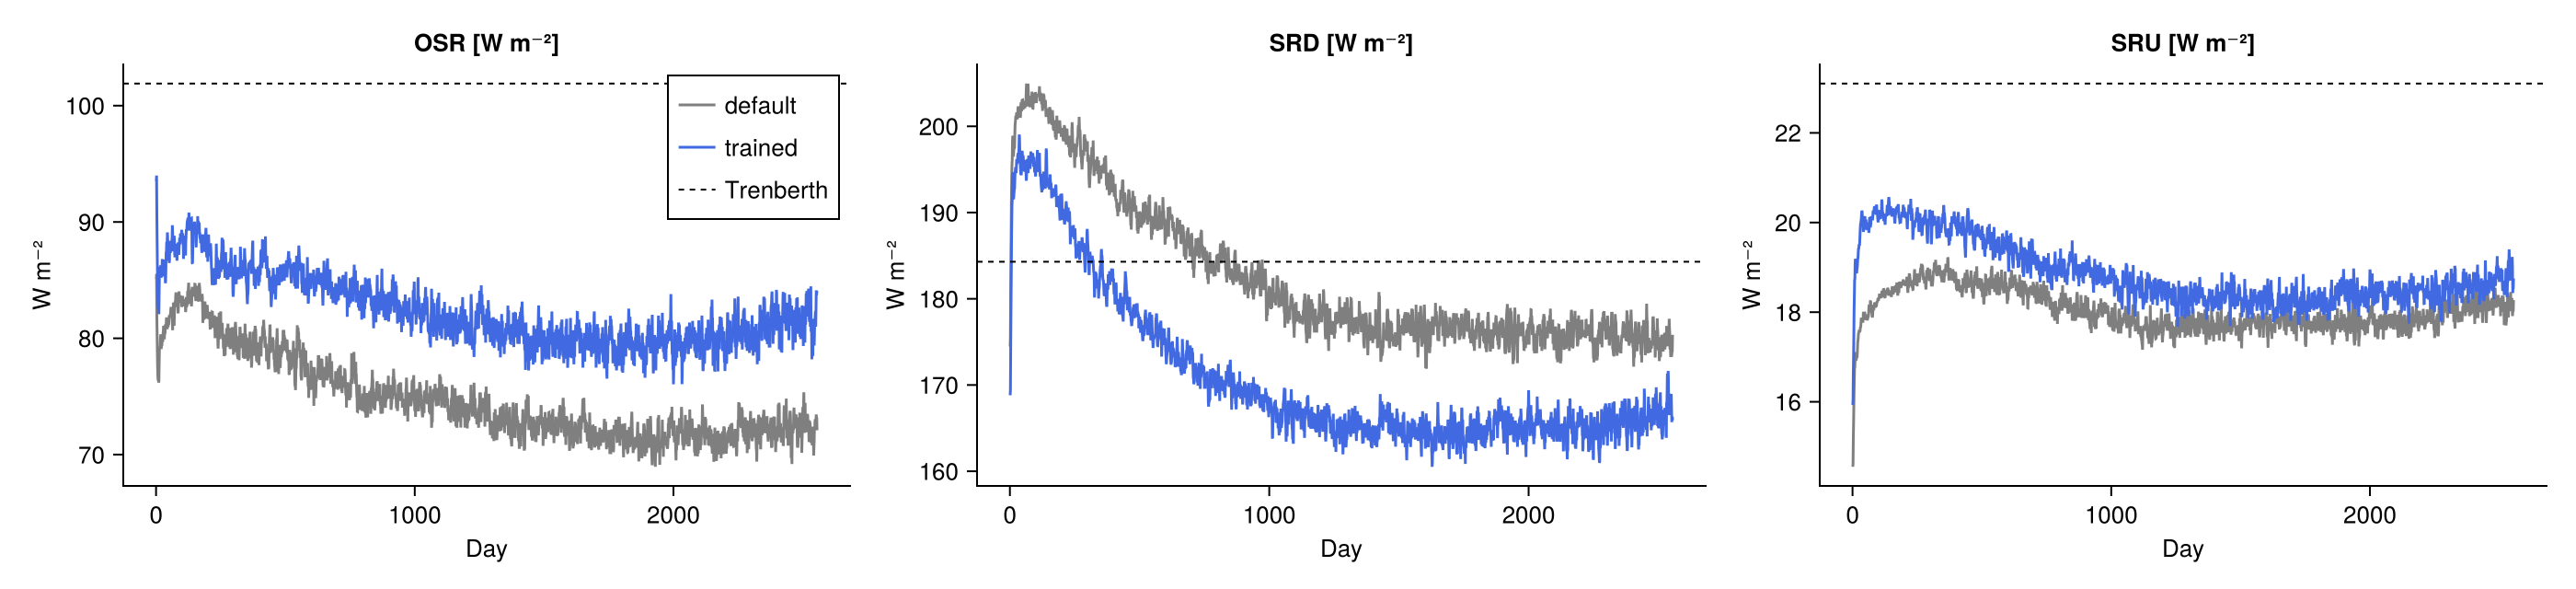

In [53]:
cfigs = plot_climate(clm;
    save_dir    = joinpath(@__DIR__, "output", "trenberth_full"),
    loss_config = result.loss_config,
)
cfigs.fig_rad

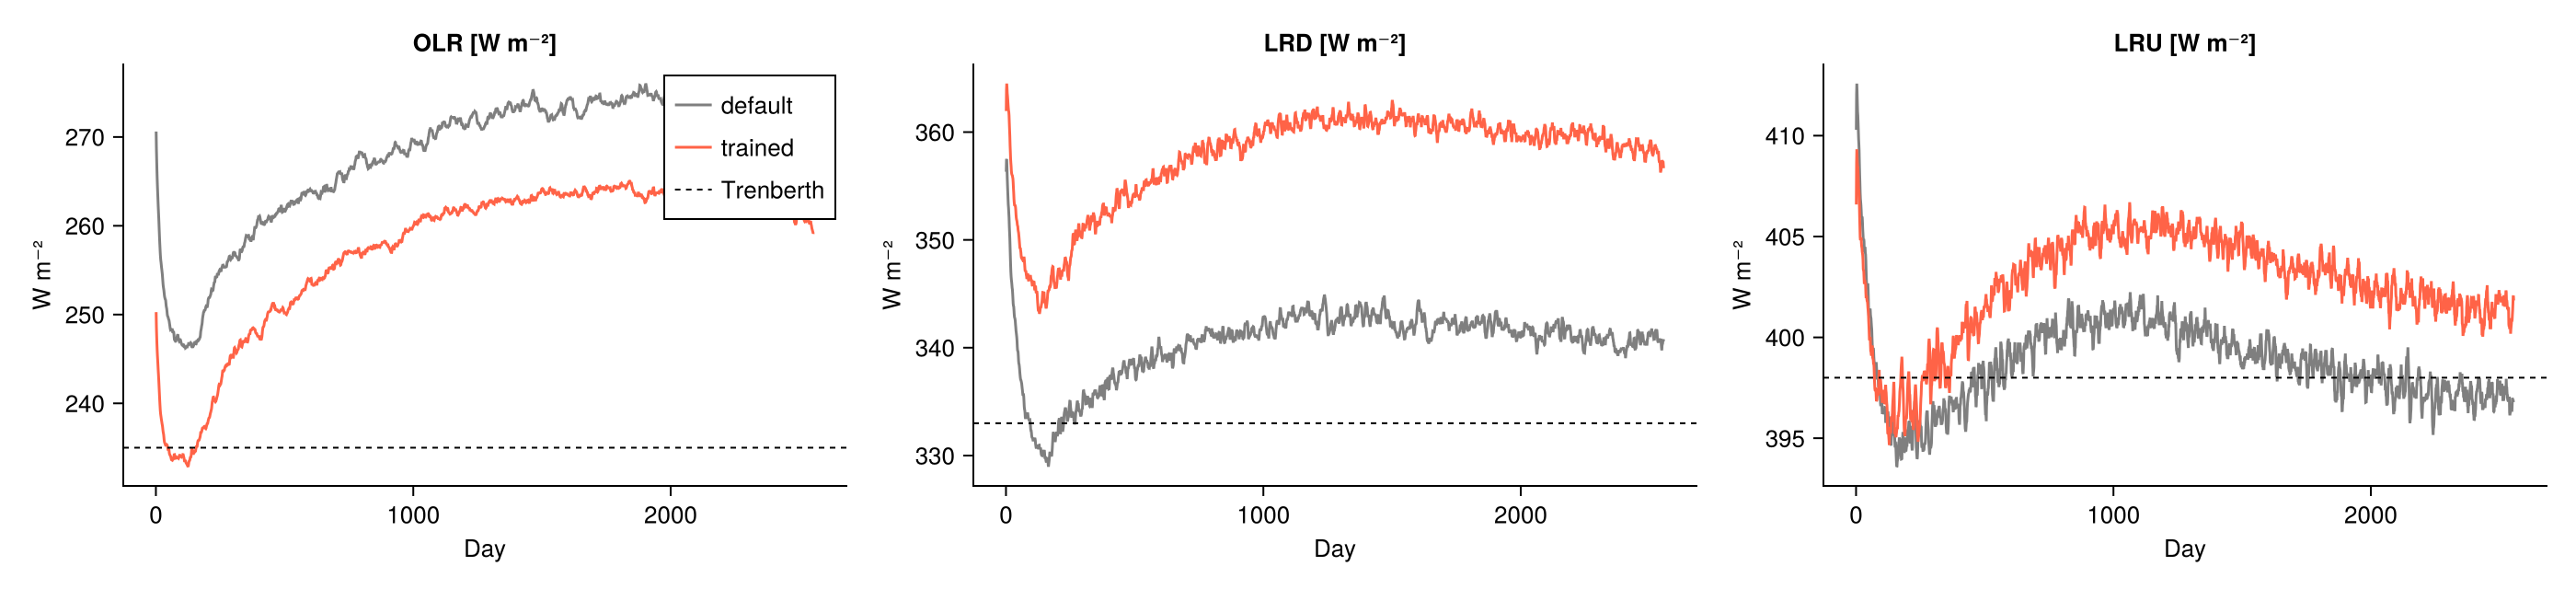

In [54]:
cfigs.fig_lw

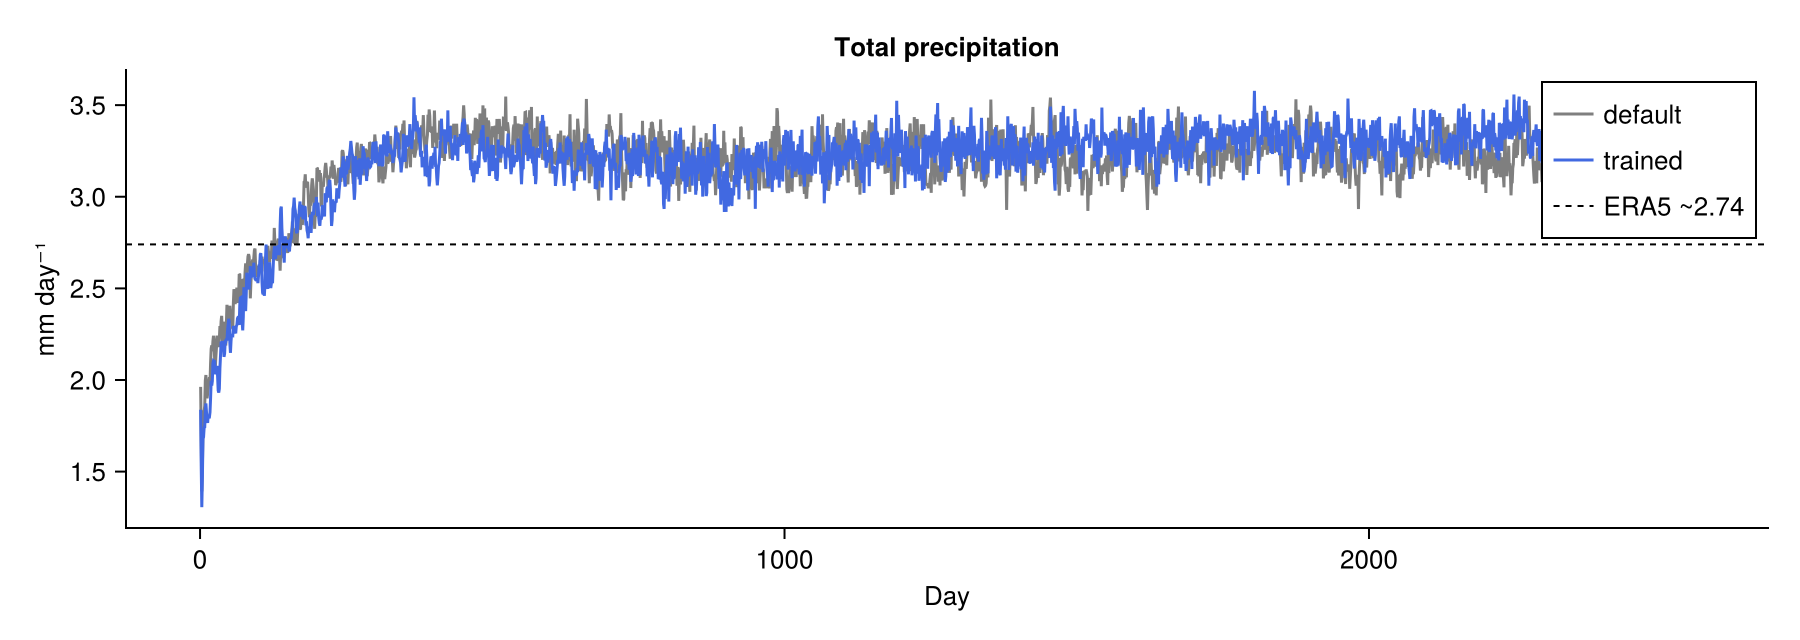

In [55]:
cfigs.fig_precip

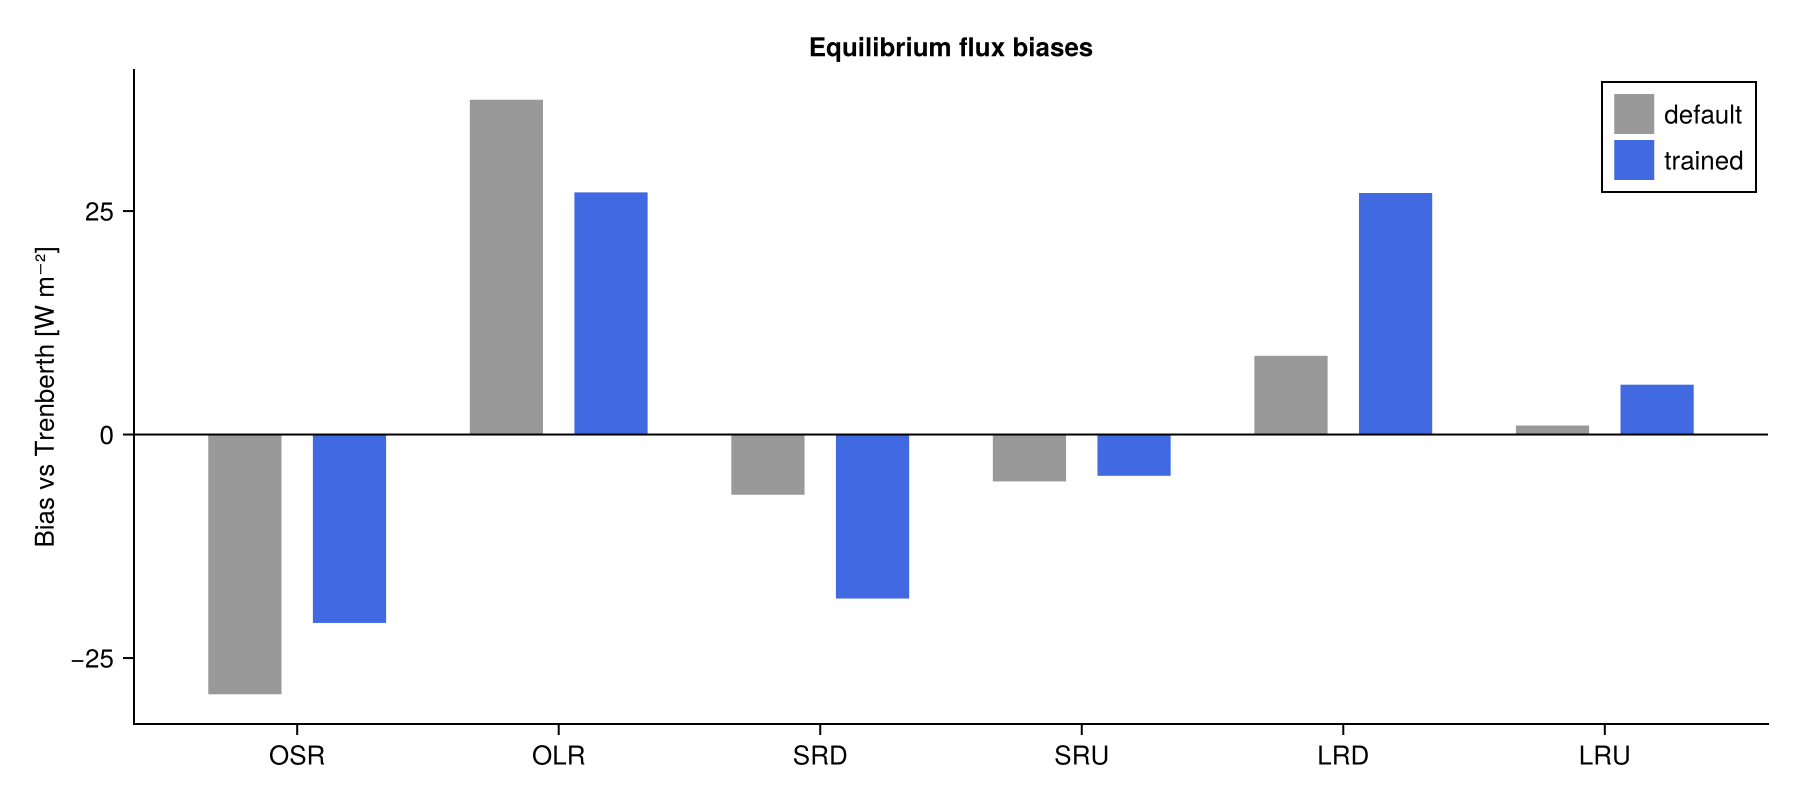

In [56]:
cfigs.fig_summary

## 9. Interpretation and Next Steps

**Reading the summary plot:**  
Each bar shows the equilibrium bias (trained value − Trenberth target) for one flux. Bars shrinking toward zero from default (grey) to trained (blue) indicate successful calibration. Watch for biases that *grow* in fluxes not in the loss — these indicate compensatory parameter adjustments.

**Common issues and fixes:**

| Symptom | Likely cause | Fix |
|---------|-------------|-----|
| Loss oscillates without decreasing | LR too high | Reduce Adam LR to `1f-3` |
| One flux improves, another degrades | Loss weights too uneven | Rebalance `TRENBERTH_LOSS` weights |
| Parameter hits its bound | Bounds too narrow | Widen the offending `ParamSpec` bounds |
| Precipitation degrades strongly | Convective params pulled too far | Add precipitation term to loss |
| Gradient ~0 for a parameter | Zero-gradient path | Exclude parameter or change its path |

**Continuing from this result:**  
Set `initial = result.final_params[spec.name]` in each `ParamSpec` and re-run with a lower LR to refine further. The sigmoid reparameterisation ensures bounds are still respected.